## Performing RFM analysis on the dataset
#### R : Recency
#### F : Frequency
#### M : Monetary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
script = Path.cwd()
root = script.parent
df=  pd.read_csv(root/"data"/'cleaned_data'/'cleaned_data.csv')

In [3]:
df.head()

,Unnamed: 0,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,0.0,18.0,F,XW0DQ7H,Village,Platinum Membership,2017-08-17,No,no referral id,Gift Vouchers/Coupons,...,300.63,53005.25,17,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0.0
1,1.0,32.0,F,5K0N3X1,City,Premium Membership,2017-08-28,No Information available,CID21329,Gift Vouchers/Coupons,...,306.34,12838.38,10,698.03,Yes,No,Yes,Solved,Quality Customer Care,0.0
2,2.0,44.0,F,1F2TCL3,Town,No Membership,2016-11-11,Yes,CID12313,Gift Vouchers/Coupons,...,516.16,21027.00,22,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1.0
3,3.0,37.0,M,VJGJ33N,City,No Membership,2016-10-29,Yes,CID3793,Gift Vouchers/Coupons,...,53.27,25239.56,6,567.66,No,Yes,Yes,Unsolved,Poor Website,1.0
4,4.0,31.0,F,SVZXCWB,City,No Membership,2017-09-12,No,no referral id,Credit/Debit Card Offers,...,113.13,24483.66,16,663.06,No,Yes,Yes,Solved,Poor Website,1.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    35273 non-null  float64
 1   age                           36992 non-null  float64
 2   gender                        36992 non-null  str    
 3   security_no                   36992 non-null  str    
 4   region_category               36992 non-null  str    
 5   membership_category           36992 non-null  str    
 6   joining_date                  36992 non-null  str    
 7   joined_through_referral       36992 non-null  str    
 8   referral_id                   36992 non-null  str    
 9   preferred_offer_types         36992 non-null  str    
 10  medium_of_operation           36992 non-null  str    
 11  internet_option               36992 non-null  str    
 12  last_visit_time               36992 non-null  str    
 13  days_since_l

In [5]:
df['avg_frequency_login_days'] = pd.to_numeric(df['avg_frequency_login_days'],errors = 'coerce')

In [6]:
# Recency
df['R_score'] = pd.qcut(df['days_since_last_login'], q=5, labels=[5,4,3,2,1])

In [7]:
# Frequency
df['F_score'] = pd.qcut(df['avg_frequency_login_days'],q=5,labels = [5,4,3,2,1])

In [8]:
# Monetary
df['M_score'] = pd.qcut(df['avg_transaction_value'],q=5,labels = [1,2,3,4,5])

In [9]:
df['RFM_score'] = (df['R_score'].astype(str) + df['F_score'].astype(str) + df['M_score'].astype(str))

In [10]:
print(df[['R_score','F_score','M_score','RFM_score']].head())

  R_score F_score M_score RFM_score
0       2       3       5     23.05
1       2       4       2     24.02
2       3       2       2     32.02
3       4       5       3     45.03
4       1       3       3     13.03


In [11]:
def label_segment(row):
    r, f, m = float(row['R_score']), float(row['F_score']), float(row['M_score'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 4 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    else:
        return 'Needs Attention'

df['segment'] = df.apply(label_segment, axis=1)
print(df['segment'].value_counts())

segment
Needs Attention    15645
Loyal Customers     6248
New Customers       5560
At Risk             4755
Champions           2726
Hibernating         2058
Name: count, dtype: int64


### Churn by segment

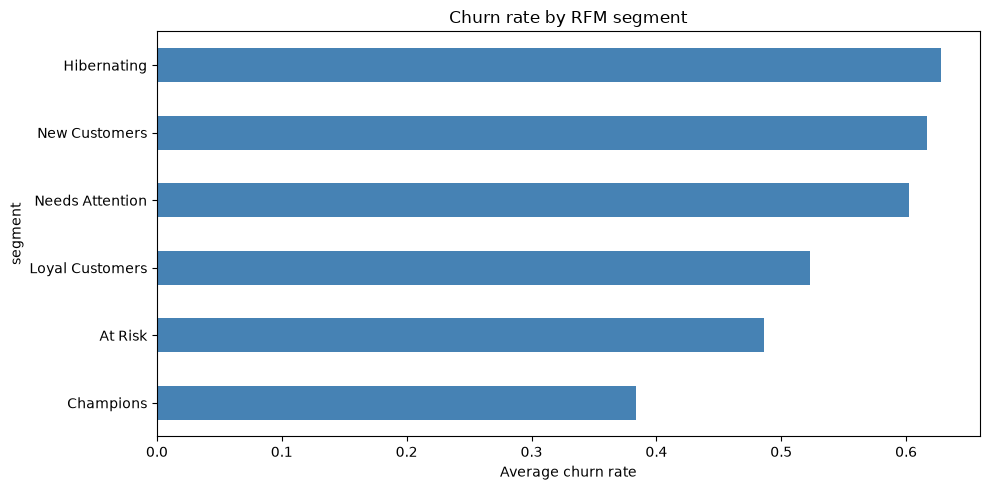

In [12]:
churn_by_segment = df.groupby('segment')['churn_risk_score'].mean().sort_values()

plt.figure(figsize=(10, 5))
churn_by_segment.plot(kind='barh', color='steelblue')
plt.xlabel('Average churn rate')
plt.title('Churn rate by RFM segment')
plt.tight_layout()
plt.show()